In [10]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import Analytic_t_dep_sim as ATDS

import A_nl_altered_sims as A_nl

import Analytic_t_dep_sim_CC_speed as ATDS_CC

import Analytic_t_dep_sim_TIDAL_HEAT as ATDS_TH

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np

import matplotlib.pyplot as plt

In [39]:

import importlib
importlib.reload(ATDS_TH)

# At M22 = 1, r_c = 0.2375 kpc

SphHT = True
integrator = 'leapfrog'
plot = False
dt_override = 20

sim = ATDS_TH.StellarSimTDep(m22 = 1, r_half = 0.02, cluster_R_orbit_kpc = 0.3, cluster_M_Msun=1e4, no_of_particles = 100, no_time_steps = 1000, total_evolve_time = 10, r_min = 0.5, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, plot = plot, dt_override=dt_override)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [ ]:
sim.run_simulation()

Cached precomputed_R_j_r_m22_1_rbins_1000.npz stale (parameter mismatch); recomputing.
l max from jaxsp: 23
Cached precomputed_Y_lm_m22_1_rbins_1000.npz stale (parameter mismatch); recomputing.
Cluster: Plummer scale a = R_1/2 = 0.0200 kpc, orbiting at R_orbit = 0.3000 kpc, v_COM = 5.393 km/s, M_c = 1.00e+04 Msun
Particle 0: |Δr| = 22.52 pc, |Δv| = 1.410 km/s
Particle 1: |Δr| = 11.26 pc, |Δv| = 1.284 km/s
Particle 2: |Δr| = 22.75 pc, |Δv| = 0.705 km/s
Particle 3: |Δr| = 62.65 pc, |Δv| = 0.554 km/s
Particle 4: |Δr| = 13.00 pc, |Δv| = 0.727 km/s
Particle 5: |Δr| = 33.55 pc, |Δv| = 0.266 km/s
Particle 6: |Δr| = 26.84 pc, |Δv| = 1.342 km/s
Particle 7: |Δr| = 57.65 pc, |Δv| = 0.712 km/s
Particle 8: |Δr| = 78.99 pc, |Δv| = 0.174 km/s
Particle 9: |Δr| = 35.14 pc, |Δv| = 0.900 km/s
Particle 10: |Δr| = 9.99 pc, |Δv| = 1.105 km/s
Particle 11: |Δr| = 23.94 pc, |Δv| = 0.441 km/s
Particle 12: |Δr| = 18.15 pc, |Δv| = 0.425 km/s
Particle 13: |Δr| = 52.80 pc, |Δv| = 0.985 km/s
Particle 14: |Δr| = 15.1

In [13]:
positions_all = np.array([p.positions_xyz for p in sim.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in sim.particles])  # (N_particles, N_steps+1)
all_vels_cart = np.array([[np.array(v) for v in p.velocities_cart] for p in sim.particles])
kinetic_energy_all = np.array([p.kinetic_energy for p in sim.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in sim.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in sim.particles]) # (N_particles, N_steps+1, 3)

(100, 645, 3)


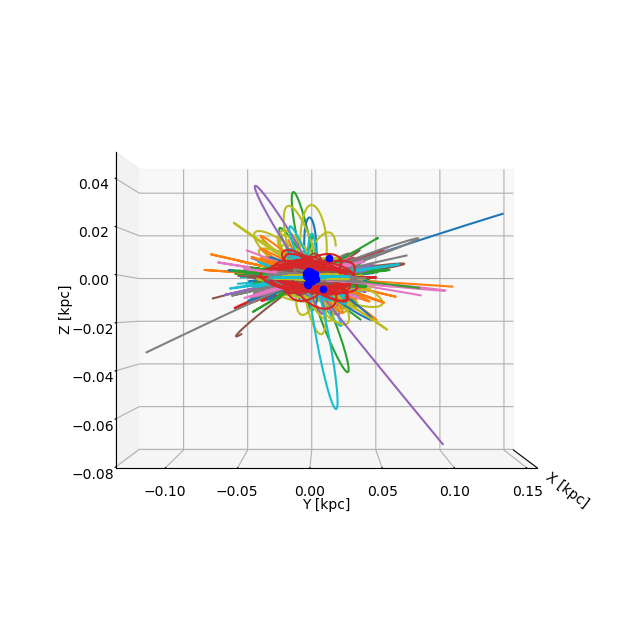

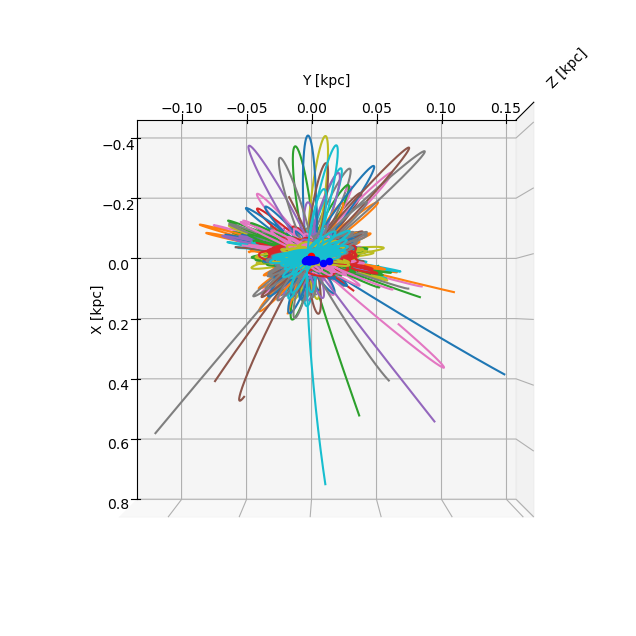

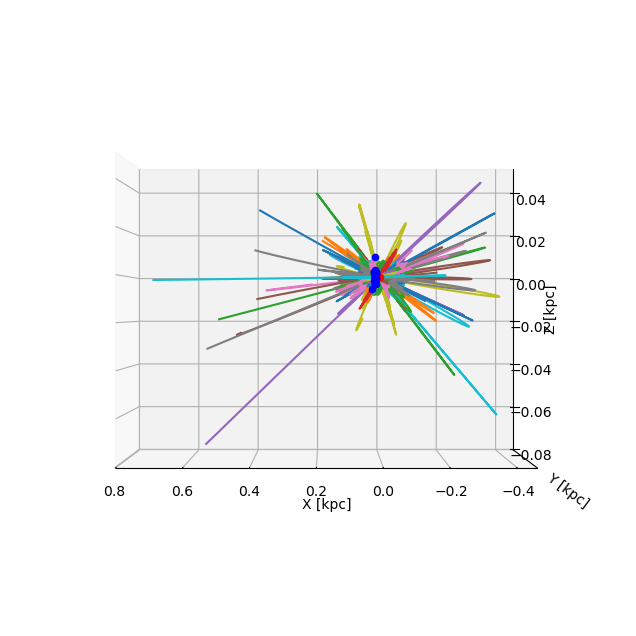

In [14]:

print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


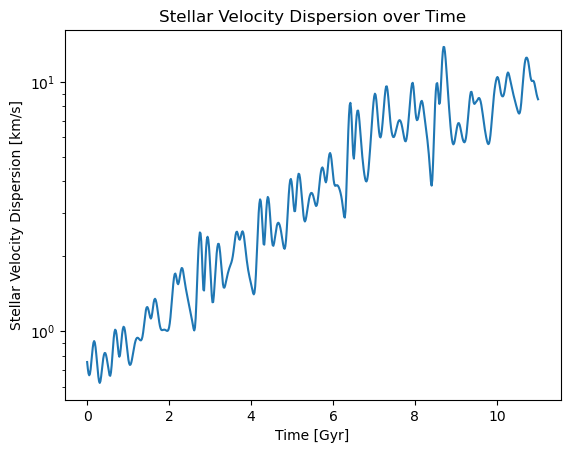

[4.38227104 4.50349571 4.94267112 4.01461401 4.6633671  4.32645234
 4.75691801 5.2712304  4.69547765 4.435511   4.68704351 4.47113165
 4.53361366 4.36347149 4.45795312 4.96016724 5.06412406 4.73639734
 4.37889447 4.50406545 4.67058817 4.28018489 5.22829675 4.63125096
 4.7811631  4.49923887 4.89723586 4.74252523 4.89962143 4.88841351
 4.82881466 4.70988844 4.17126512 5.31121869 5.1986975  4.92549005
 4.57341373 4.61067597 7.36824506 4.67508129 4.94397289 4.91030509
 4.55567304 4.26783688 4.68756268 4.51778404 5.15647602 5.08365245
 4.70218158 4.86353804 5.1720224  4.55908616 5.9126717  4.73942267
 5.06068102 4.85324165 4.35996041 4.75607568 4.59629137 4.67177017
 4.49326003 3.90890182 4.80020939 4.74986653 4.75399928 4.30041423
 4.697238   4.99024505 5.97234619 4.87228806 5.4247699  4.73015123
 4.6095973  4.70188893 4.52804927 4.31366793 4.81465218 4.68316704
 4.16705427 4.39297508 4.25912975 4.5206568  4.64387337 4.81237085
 4.69090951 4.66467852 4.51170341 4.62433221 4.38565906 3.9538

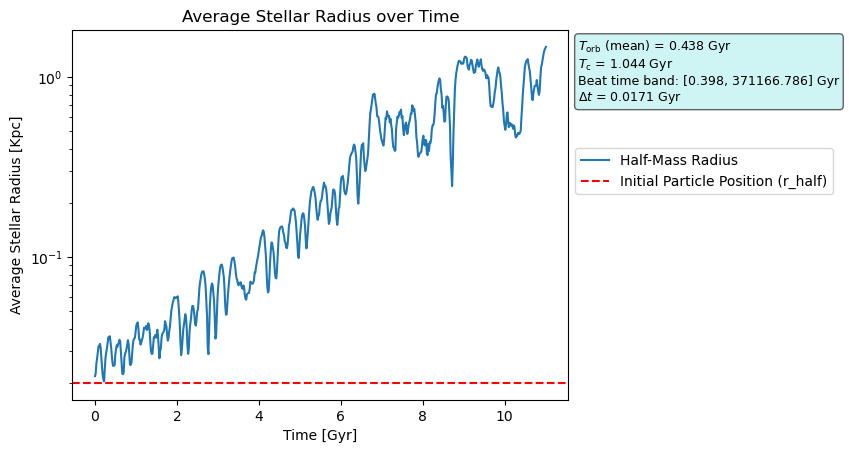

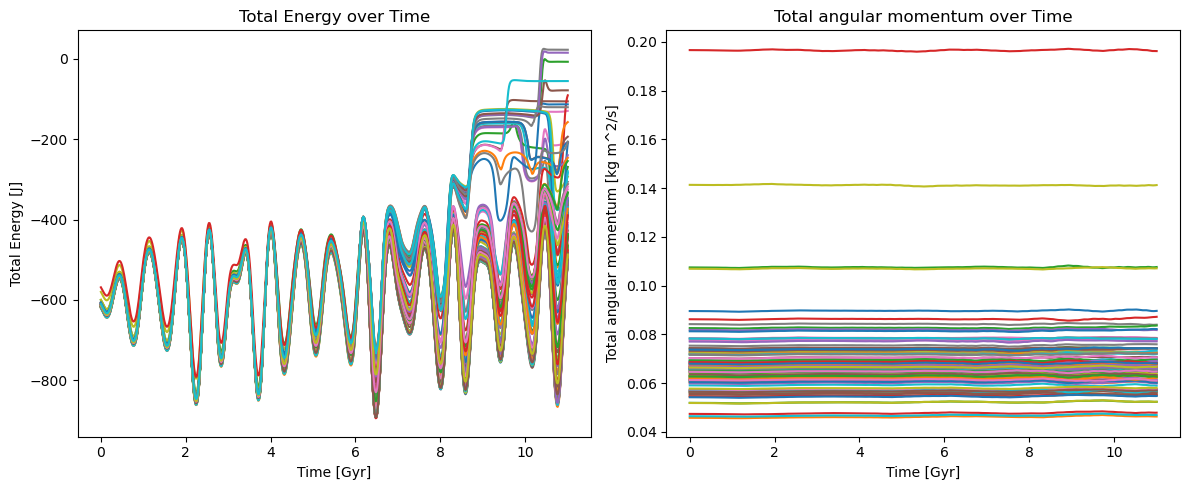

In [ ]:
no_time_steps = sim.no_time_steps
# std across particles (axis=0) at each timestep → shape (n_timesteps,)
stellar_v_disp2 = np.sqrt(
    np.std(all_vels_cart[:, :, 0], axis=0)**2 +
    np.std(all_vels_cart[:, :, 1], axis=0)**2 +
    np.std(all_vels_cart[:, :, 2], axis=0)**2
)

com_xy = positions_all[:, :, :2].mean(axis=0)            # (Nsteps, 2) — empirical COM
offsets_xy = positions_all[:, :, :2] - com_xy[None, :, :]
R_half = np.median(np.sqrt(offsets_xy[:, :, 0]**2 + offsets_xy[:, :, 1]**2), axis=0)



x = np.arange(no_time_steps + 1)  # Time steps array


plt.plot(x * sim.dt * sim.u.to_Gyr, stellar_v_disp2 * sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * sim.dt * sim.u.to_Gyr, R_half * sim.u.to_Kpc, label='Half-Mass Radius')
#for particle in range(r_all.shape[0]):
    #plt.plot(x * sim.dt * sim.u.to_Gyr, com_xy[particle, :, 0] * sim.u.to_Kpc, alpha = 0.2, color='gray')
plt.axhline(sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.yscale('log')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')

# Timescale diagnostics
v0 = np.linalg.norm(all_vels_cart[:, 0, :], axis=1)
mean_T_orb = float(np.mean(2 * np.pi * r_all[:, 0] / v0) * sim.u.to_Gyr)

lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr

#plt.axhline(np.mean(lambda_db_kpc), color='g', linestyle='--', label='$\\lambda_{{\\rm db}}$')


E = np.array(sim.eigen_energies)
freq_diff = np.abs(E[:, None] - E[None, :])
T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

dt_Gyr = sim.dt * sim.u.to_Gyr

info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_{{\\rm c}}$ = {float(np.mean(T_c)):.3f} Gyr\n"
    f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)

plt.text(1.02, 0.98, info, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='paleturquoise', alpha=0.6))

plt.legend(bbox_to_anchor=(1, 0.7))
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * sim.dt * sim.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * sim.dt * sim.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()


In [ ]:
import importlib
importlib.reload(ATDS_CC)

# At M22 = 1, r_c = 0.2375 kpc

SphHT = True
integrator = 'ias15'
plot = False
dt_override = None

sim = ATDS_TH.StellarSimTDep(m22 = 2, r_half = 0.19, no_of_particles = 5, no_time_steps = 100, total_evolve_time = 10, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, plot = plot, dt_override=dt_override)

In [ ]:
sim.run_simulation()

Loading precomputed R_j_r from precomputed_R_j_r_m22_1_rbins_1000.npz...
l max from jaxsp: 23
Loading precomputed Y_lm and lm_pairs from precomputed_Y_lm_m22_1_rbins_1000.npz...
Cluster: Plummer scale a = R_1/2 = 0.0200 kpc, orbiting at R_orbit = 0.3000 kpc, v_COM = 5.393 km/s, M_c = 1.00e+04 Msun
Particle 0: |Δr| = 22.52 pc, |Δv| = 1.410 km/s
Particle 1: |Δr| = 11.26 pc, |Δv| = 1.284 km/s
Particle 2: |Δr| = 22.75 pc, |Δv| = 0.705 km/s
Particle 3: |Δr| = 62.65 pc, |Δv| = 0.554 km/s
Particle 4: |Δr| = 13.00 pc, |Δv| = 0.727 km/s
Particle 5: |Δr| = 33.55 pc, |Δv| = 0.266 km/s
Particle 6: |Δr| = 26.84 pc, |Δv| = 1.342 km/s
Particle 7: |Δr| = 57.65 pc, |Δv| = 0.712 km/s
Particle 8: |Δr| = 78.99 pc, |Δv| = 0.174 km/s
Particle 9: |Δr| = 35.14 pc, |Δv| = 0.900 km/s
Particle 10: |Δr| = 9.99 pc, |Δv| = 1.105 km/s
Particle 11: |Δr| = 23.94 pc, |Δv| = 0.441 km/s
Particle 12: |Δr| = 18.15 pc, |Δv| = 0.425 km/s
Particle 13: |Δr| = 52.80 pc, |Δv| = 0.985 km/s
Particle 14: |Δr| = 15.19 pc, |Δv| = 1.1

# Altering the original $a_{nl}$ coefficients so states with larger (n,l) have higher $a_{nl}$
### First altering n,l states which correspond to periods of oscillation that are close to the orbital period of test masses
### Keeping sum of a_nl un-normalised so the period of the orbits dont change after chainging the $a_{nl}$

In [ ]:

import importlib
importlib.reload(A_nl)

animate = False
SphHT = False
integrator = 'leapfrog'
a_nl_range = 'orbital'
plot = True

sim = A_nl.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 5, no_time_steps = 1000, total_evolve_time = 10, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, a_nl_range= a_nl_range, plot = plot, boost_factor=1e3, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [8]:
sim.run_simulation()

l max from jaxsp: 47


KeyboardInterrupt: 

In [4]:
positions_all = np.array([p.positions_xyz for p in sim.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in sim.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in sim.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in sim.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in sim.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in sim.particles]) # (N_particles, N_steps+1, 3)

(5, 1501, 3)


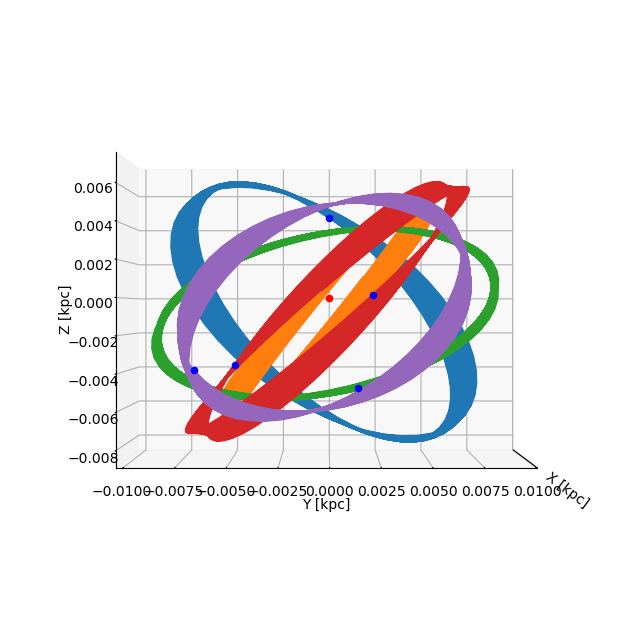

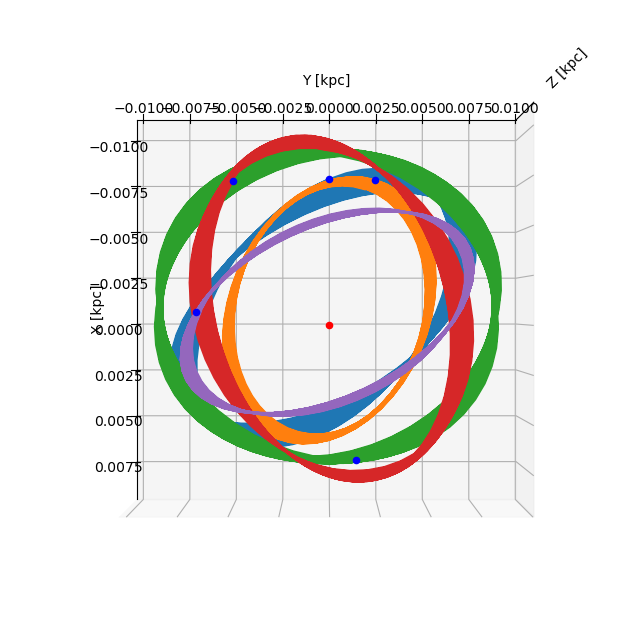

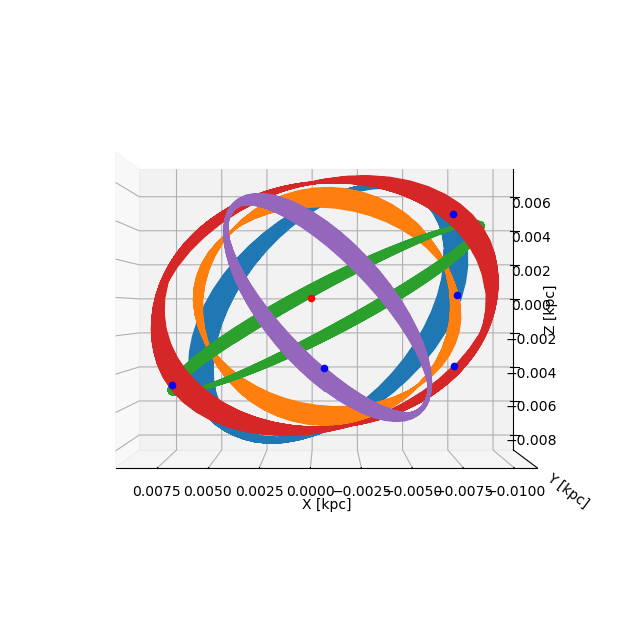

In [5]:
print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [ ]:
time_step2 = sim.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * sim.dt * sim.u.to_Gyr, stellar_v_disp2 * sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * sim.dt * sim.u.to_Gyr, average_r2 * sim.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[particle] * sim.u.to_Kpc, alpha = 0.2, color='gray')
plt.axhline(sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')

# Timescale diagnostics
v0 = np.sqrt(2 * kinetic_energy_all[:, 0])
mean_T_orb = float(np.mean(2 * np.pi * r_all[:, 0] / v0) * sim.u.to_Gyr)

lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr


E = np.array(sim.eigen_energies)
freq_diff = np.abs(E[:, None] - E[None, :])
T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

dt_Gyr = sim.dt * sim.u.to_Gyr


info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_{{\\rm c}}$ = {float(T_c[0]):.3f} Gyr\n"
    f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)
plt.text(0.02, 0.98, info, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.legend(loc = 'lower right')
plt.show()



fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * sim.dt * sim.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * sim.dt * sim.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()


## Altering large period $a_{nl}$ coeffs

In [2]:

import importlib
importlib.reload(A_nl)

animate = False
SphHT = False
integrator = 'leapfrog'
a_nl_range = 'large'
plot = True

sim = A_nl.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 5, no_time_steps = 500, total_evolve_time = 10, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, a_nl_range= a_nl_range, plot = plot, boost_factor=1e5, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


l max from jaxsp: 23


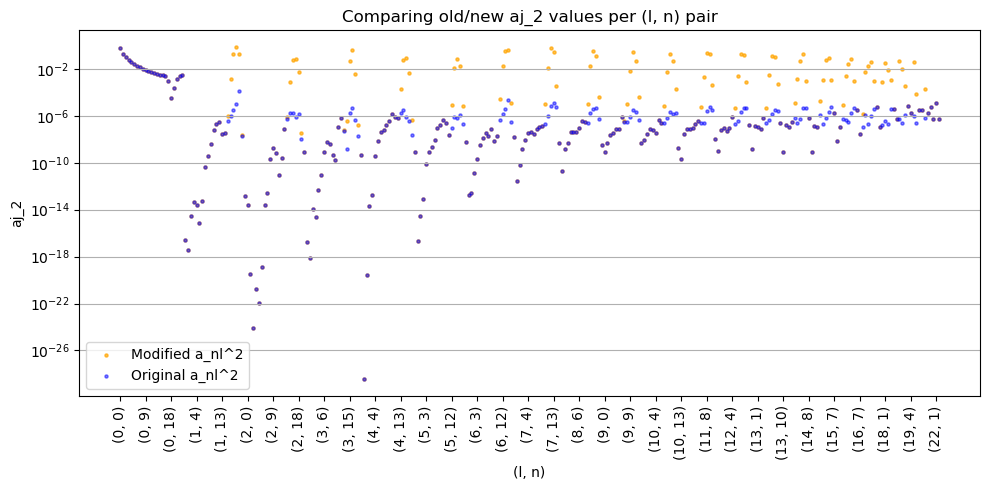

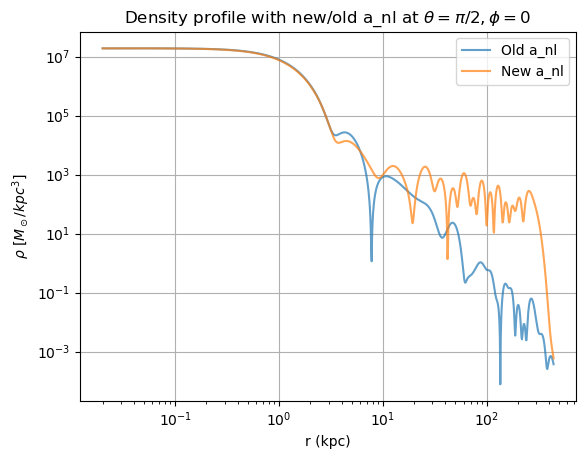

Particle 0: v_circ = 3.404 km/s
Particle 1: v_circ = 3.070 km/s
Particle 2: v_circ = 3.409 km/s
Particle 3: v_circ = 3.847 km/s
Particle 4: v_circ = 3.138 km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...
Time step 1 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.94 seconds
Time step 2 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.61 seconds
Time step 3 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.60 seconds
Time step 4 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.48 seconds
Time step 5 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.69 seconds
Time step 6 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.70 seconds
Time step 7 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.66 seconds
Time step 8 / 500
  Force calls this timestep: 1
Time stepping all

In [3]:
sim.run_simulation()

In [4]:
positions_all = np.array([p.positions_xyz for p in sim.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in sim.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in sim.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in sim.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in sim.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in sim.particles]) # (N_particles, N_steps+1, 3)

(5, 501, 3)


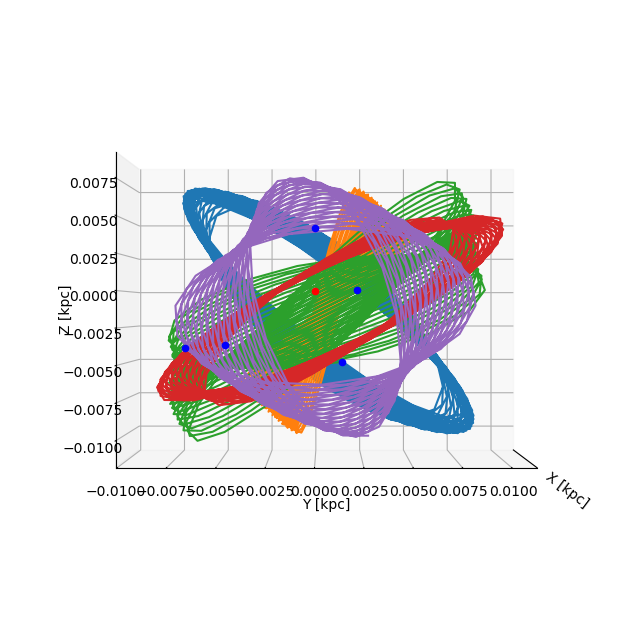

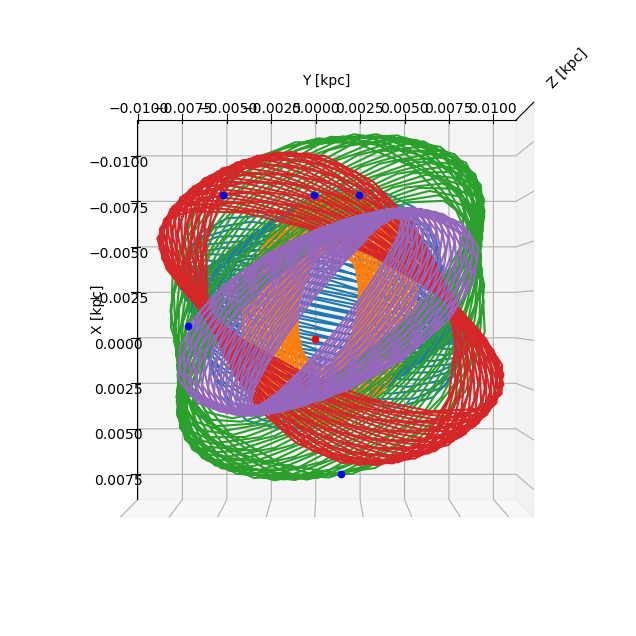

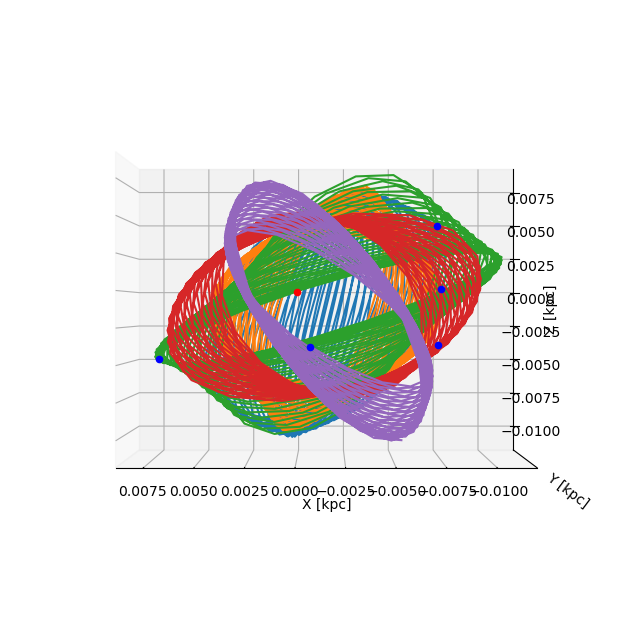

In [5]:
print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [ ]:
time_step2 = sim.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * sim.dt * sim.u.to_Gyr, stellar_v_disp2 * sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * sim.dt * sim.u.to_Gyr, average_r2 * sim.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[particle] * sim.u.to_Kpc, alpha = 0.2, color='gray')
plt.axhline(sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')

# Timescale diagnostics
v0 = np.sqrt(2 * kinetic_energy_all[:, 0])
mean_T_orb = float(np.mean(2 * np.pi * r_all[:, 0] / v0) * sim.u.to_Gyr)

lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr


E = np.array(sim.eigen_energies)
freq_diff = np.abs(E[:, None] - E[None, :])
T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

dt_Gyr = sim.dt * sim.u.to_Gyr


info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_{{\\rm c}}$ = {float(T_c[0]):.3f} Gyr\n"
    f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)
plt.text(0.02, 0.98, info, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.legend(loc = 'lower right')
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * sim.dt * sim.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * sim.dt * sim.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()


## Altering small period $a_{nl}$ coeffs

In [2]:

import importlib
importlib.reload(A_nl)

animate = False
SphHT = False
integrator = 'leapfrog'
a_nl_range = 'small'
plot = True

sim = A_nl.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 5, no_time_steps = 500, total_evolve_time = 10, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, a_nl_range= a_nl_range, plot = plot, boost_factor=1e6, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


l max from jaxsp: 23


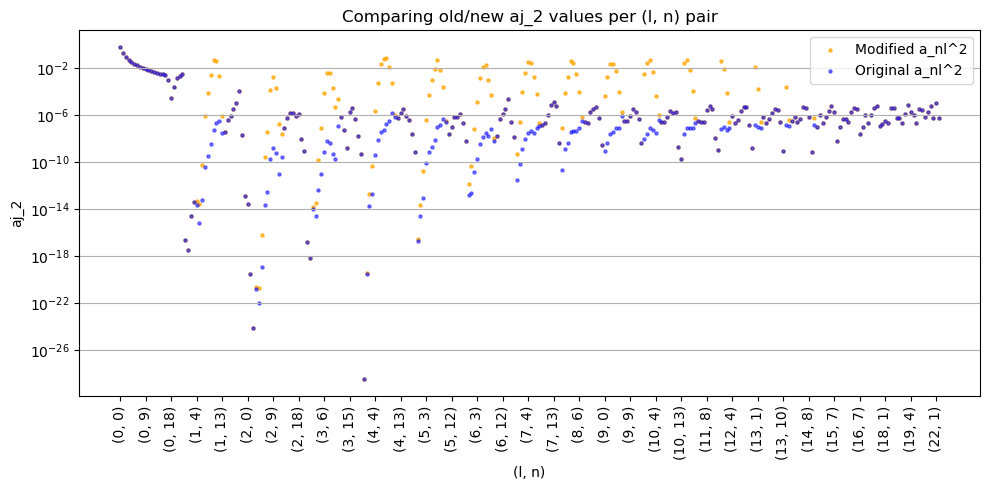

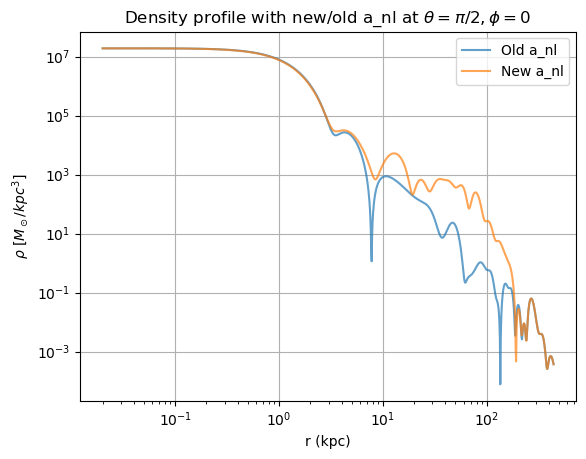

Particle 0: v_circ = 3.404 km/s
Particle 1: v_circ = 3.070 km/s
Particle 2: v_circ = 3.409 km/s
Particle 3: v_circ = 3.847 km/s
Particle 4: v_circ = 3.138 km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...
Time step 1 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.82 seconds
Time step 2 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.61 seconds
Time step 3 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.62 seconds
Time step 4 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.49 seconds
Time step 5 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.70 seconds
Time step 6 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.68 seconds
Time step 7 / 500
  Force calls this timestep: 1
Time stepping all particles completed in 0.63 seconds
Time step 8 / 500
  Force calls this timestep: 1
Time stepping all

In [3]:
sim.run_simulation()

In [4]:
positions_all = np.array([p.positions_xyz for p in sim.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in sim.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in sim.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in sim.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in sim.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in sim.particles]) # (N_particles, N_steps+1, 3)

(5, 501, 3)


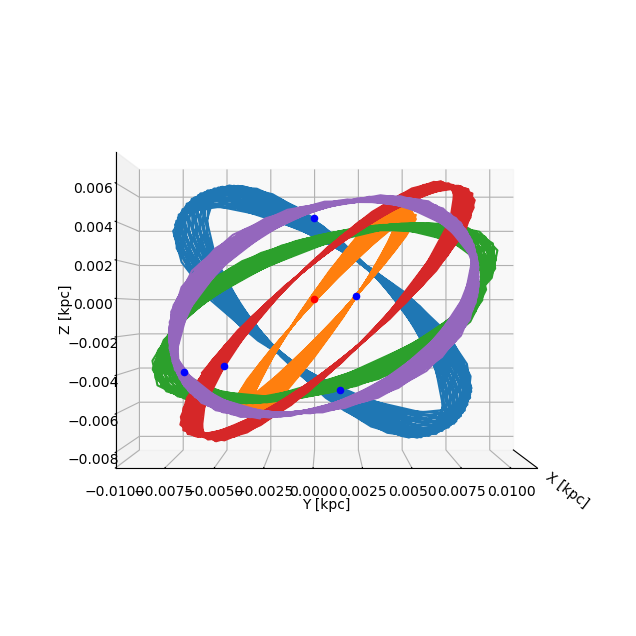

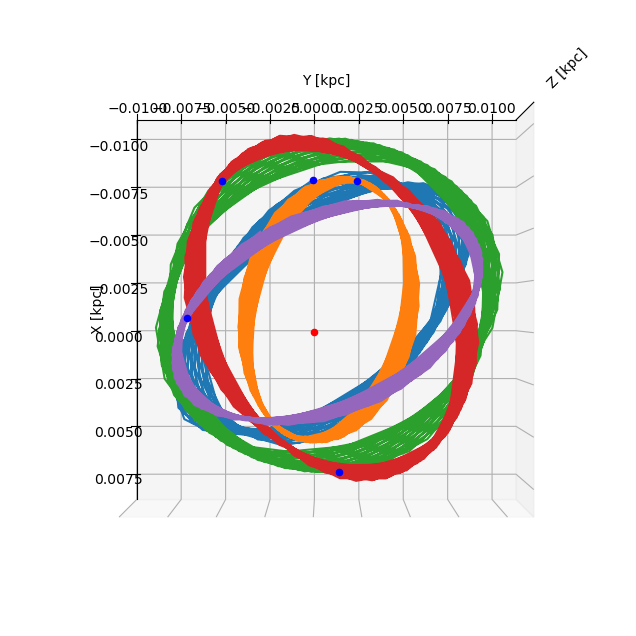

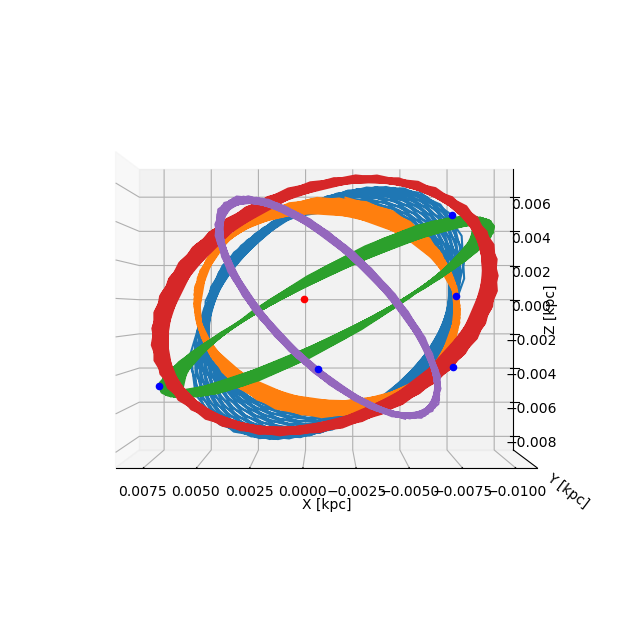

In [5]:
print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [ ]:
time_step2 = sim.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * sim.dt * sim.u.to_Gyr, stellar_v_disp2 * sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * sim.dt * sim.u.to_Gyr, average_r2 * sim.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[particle] * sim.u.to_Kpc, alpha = 0.2, color='gray')
plt.axhline(sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')

# Timescale diagnostics
v0 = np.sqrt(2 * kinetic_energy_all[:, 0])
mean_T_orb = float(np.mean(2 * np.pi * r_all[:, 0] / v0) * sim.u.to_Gyr)

lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr


E = np.array(sim.eigen_energies)
freq_diff = np.abs(E[:, None] - E[None, :])
T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

dt_Gyr = sim.dt * sim.u.to_Gyr


info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_{{\\rm c}}$ = {float(T_c[0]):.3f} Gyr\n"
    f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)
plt.text(0.02, 0.98, info, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.legend(loc = 'lower right')
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * sim.dt * sim.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * sim.dt * sim.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()
